# 01 — Quickstart: VCBench with four reasoning methods

**Start here.** About 5 minutes, precomputed scores, no Ollama needed. This
notebook reads four CSV files that ship with the example and nothing else: no
LLM calls, no API key, no raw dataset, no network.

**VCBench** is a founder-success benchmark. Given anonymised prose about a
founder, predict whether they went on to succeed. The public split is 4,500
founders with a base rate near 9%, so the classes are heavily imbalanced and
ROC-AUC alone does not tell the whole story.

The four TRL reasoning methods, one line each:

- **PolicyInduction (PI)** — induces a handful of natural-language policies from
  the training founders, applies each one to every founder with the LLM, and
  weights the answers with a logistic regression.
- **RRF** — an ensemble over LLM-generated YES/NO questions. A shortlist of
  questions is put to the LLM about each founder and the answer vector is
  collapsed into a score.
- **GPTree** — a decision tree whose splits are questions the LLM answers about
  a founder rather than numeric thresholds.
- **RRM (Reasoned Rule Mining)** — mines natural-language IF-THEN rules out of
  the LLM's reasoning over labelled founders, compiles the survivors into one
  decision policy, and predicts with a confidence-weighted vote and a calibrator.

All four were run once on a reference machine against a local
`qwen2.5-coder:14b` served by Ollama. Their per-founder scores are what you load
below. Notebook 02 opens the models those runs produced.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score


def find_example_root(start: Path | None = None) -> Path:
    """Walk up from `start` (default: the CWD) to the example dir holding precomputed/."""
    start = (start or Path.cwd()).resolve()
    for parent in (start, *start.parents):
        for candidate in (parent, parent / "examples" / "vcbench-movie-local"):
            if (candidate / "precomputed").is_dir():
                return candidate
    raise FileNotFoundError(
        "Could not find the example directory (the one containing precomputed/) "
        f"above {start}. Run this notebook from inside the example."
    )


EXAMPLE_ROOT = find_example_root()
PRECOMPUTED = EXAMPLE_ROOT / "precomputed"

print("example root:", EXAMPLE_ROOT.name)
print("score files: ", len(sorted(PRECOMPUTED.glob("vcbench_*_scores.csv"))))

example root: vcbench-movie-local
score files:  8


In [2]:
METHODS = {"pi": "PI", "rrf": "RRF", "gptree": "GPTree", "rrm": "RRM"}

frames = []
for key, name in METHODS.items():
    df = pd.read_csv(PRECOMPUTED / f"vcbench_public_{key}_scores.csv")
    frames.append(df.assign(method=name))
public = pd.concat(frames, ignore_index=True)[["method", "id", "score", "label"]]

# All four methods scored the same 4,500 founders, and the label travels with the id.
assert public.groupby("method").size().eq(4500).all()
id_sets = {name: set(g["id"]) for name, g in public.groupby("method")}
assert all(ids == id_sets["PI"] for ids in id_sets.values())
assert public.groupby("id")["label"].nunique().eq(1).all()

founders = public.groupby("id")["label"].first()
print(f"{len(public):,} rows · {len(founders):,} founders · base rate {founders.mean():.3f}")
public.head()

18,000 rows · 4,500 founders · base rate 0.090


,method,id,score,label
0,PI,18f41c84-4a6d-4cf9-bef0-c59ed0670a5c,0.482739,0
1,PI,0cd5d60d-4a6f-400f-842b-d14fa5203018,0.497916,0
2,PI,715da35c-bd62-4b6d-ad45-32ff1de2a0e1,0.803212,0
3,PI,2f2e78a6-a5d9-4f5d-907e-72f5bc86379b,0.215592,0
4,PI,b5018d33-b047-4738-8d6d-b99040cf8318,0.358672,0


## How each method scores on public CV

Two metrics, because the classes are imbalanced:

- **ROC-AUC** — the chance that a randomly chosen success is ranked above a
  randomly chosen non-success. 0.5 is a coin flip.
- **PR-AUC** (average precision) — area under the precision/recall curve. Its
  chance level is the base rate, about 0.09 here, so 0.18 is roughly twice as
  good as guessing.

The `score` column is already each method's final scalar under the operator this
example ships: PI and RRF answer vectors collapsed by an out-of-fold logistic
regression, GPTree and RRM their native probabilities. So we score `label`
against `score` directly.

In [3]:
def score_ranking(labels, scores) -> dict[str, float]:
    return {
        "ROC-AUC": roc_auc_score(labels, scores),
        "PR-AUC": average_precision_score(labels, scores),
    }


per_method = (
    pd.DataFrame(
        [{"Method": name, **score_ranking(g["label"], g["score"])} for name, g in public.groupby("method")]
    )
    .set_index("Method")
    .loc[list(METHODS.values())]
)

per_method.round(4)

,ROC-AUC,PR-AUC
Method,,
PI,0.6763,0.1831
RRF,0.6604,0.1689
GPTree,0.6161,0.1320
RRM,0.6665,0.1725


## The reasoning ensemble

The four methods disagree in useful ways, so averaging them should help. But
their raw scores live on incompatible scales — GPTree's leaf probabilities top
out around 0.36 while RRF spans most of the unit interval — and averaging those
directly would let the widest-spread method dominate the result.

Ranks remove the problem. Convert each method's scores to percentile ranks
within the split, then average the four ranks per founder. Every method now
contributes the same range, and only its *ordering* of founders survives, which
is all a ranking metric reads anyway.

In [4]:
wide = public.pivot(index="id", columns="method", values="score")[list(METHODS.values())]
labels = founders.reindex(wide.index)

ranks = wide.rank(pct=True)     # percentile rank within the split, one column per method
ensemble = ranks.mean(axis=1)   # the reasoning ensemble

ENSEMBLE = "Reasoning ensemble"
public_results = pd.concat(
    [per_method, pd.DataFrame([score_ranking(labels, ensemble)], index=[ENSEMBLE])]
)
public_results.index.name = "Method"

public_results.round(4)

,ROC-AUC,PR-AUC
Method,,
PI,0.6763,0.1831
RRF,0.6604,0.1689
GPTree,0.6161,0.1320
RRM,0.6665,0.1725
Reasoning ensemble,0.7188,0.2072


In [5]:
# The same numbers from the reference run these CSVs came from. If your output
# drifts from these, something in the load or the ensemble changed — the shipped
# scores did not.
REFERENCE_PUBLIC = {
    "PI": (0.6763, 0.1831),
    "RRF": (0.6604, 0.1689),
    "GPTree": (0.6161, 0.1320),
    "RRM": (0.6665, 0.1725),
    ENSEMBLE: (0.7188, 0.2072),
}
for method, (roc, pr) in REFERENCE_PUBLIC.items():
    row = public_results.loc[method]
    assert np.isclose(row["ROC-AUC"], roc, atol=1e-3), (method, "ROC-AUC", row["ROC-AUC"], roc)
    assert np.isclose(row["PR-AUC"], pr, atol=1e-3), (method, "PR-AUC", row["PR-AUC"], pr)

print("All five rows match the reference run to within 0.001.")

All five rows match the reference run to within 0.001.


## The number to beat (private target)

VCBench has a second split of 4,500 founders that is held out. Its labels are
the benchmark's real target and they are deliberately **not** in this repo: if
the answers shipped with the example, you could tune against them and the number
would stop meaning anything.

So the table below is a static reference — what the same four methods and the
same rank-average ensemble scored on the private split when the maintainers ran
them. The per-founder private scores are in
`precomputed/vcbench_private_*_scores.csv` if you want to look at them, but they
carry no `label` column, so these metrics cannot be recomputed here. That is the
point.

Two things worth noticing. GPTree falls off a cliff (0.6161 public → 0.5268
private, barely above chance) while RRF and RRM barely move, so a good public
number is not a promise about held-out data. And the ensemble still has the best
private ROC-AUC of the five, which is the practical argument for ensembling: you
do not have to guess in advance which method will hold up. It is not a free
lunch, though — RRF alone gets a better private PR-AUC (0.2262 vs 0.2129), so
which one you would rather ship depends on the metric you are judged on.

In [6]:
# Static reference, not computed: the private split's labels are not in this
# repo, by design. Source: the maintainers' reference run (same models, same
# operator, same rank-average ensemble as above).
private_results = pd.DataFrame(
    [
        ("PI", 0.6556, 0.1740),
        ("RRF", 0.6681, 0.2262),
        ("GPTree", 0.5268, 0.1053),
        ("RRM", 0.6662, 0.1638),
        (ENSEMBLE, 0.6850, 0.2129),
    ],
    columns=["Method", "ROC-AUC", "PR-AUC"],
).set_index("Method")

private_results

,ROC-AUC,PR-AUC
Method,,
PI,0.6556,0.1740
RRF,0.6681,0.2262
GPTree,0.5268,0.1053
RRM,0.6662,0.1638
Reasoning ensemble,0.6850,0.2129


## At a glance

Public-split ROC-AUC, all of it computed above. The dark bar is the ensemble you
just built; the lighter bars are its four members.

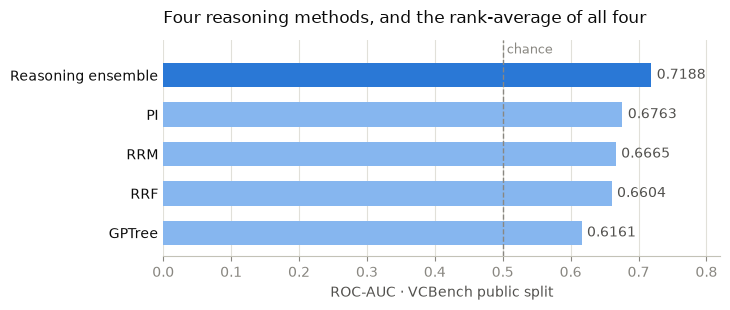

In [7]:
plot_df = public_results.sort_values("ROC-AUC")
colors = ["#2a78d6" if name == ENSEMBLE else "#86b6ef" for name in plot_df.index]

fig, ax = plt.subplots(figsize=(7.4, 3.2))
bars = ax.barh(plot_df.index, plot_df["ROC-AUC"], color=colors, height=0.62)
for bar, value in zip(bars, plot_df["ROC-AUC"]):
    ax.text(
        value + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=10,
        color="#52514e",
    )

ax.axvline(0.5, color="#898781", linewidth=1, linestyle="--")
ax.text(0.506, len(plot_df) - 0.35, "chance", fontsize=9, color="#898781", va="center")

ax.set_xlim(0, 0.82)
ax.set_ylim(-0.6, len(plot_df) - 0.1)
ax.set_xlabel("ROC-AUC · VCBench public split", color="#52514e")
ax.set_title("Four reasoning methods, and the rank-average of all four", color="#0b0b0b", loc="left", pad=12)
ax.xaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="x", colors="#898781")
ax.tick_params(axis="y", colors="#0b0b0b", length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")

fig.tight_layout()
plt.show()

## Where next

- **[02 — Reasoning methods](02_reasoning_methods.ipynb)** opens the four shipped
  models, the policies, questions, tree and rules these scores came out of, and
  makes one live call to the local model so you can see it answering.
- **[03 — Traditional baselines](03_traditional_baselines.ipynb)** adds the
  five-model sklearn suite over text length, sentence embeddings and TF-IDF.
  That is the bar reasoning methods have to clear, and on VCBench it is a
  higher bar than the chart above might suggest.
- **[04 — Ensembling](04_ensembling.ipynb)** combines the two families, which is
  the example's actual thesis: traditional and reasoning models make different
  mistakes, so combining them is worth more than picking a winner.

Notebooks 02 to 04 run from the shipped files too. Only their optional live cells
need the raw data, a network or a running Ollama, and each one skips itself
without them. The example README covers all three.